In [1]:
import pandas as pd, numpy as np
from scipy import stats
import pingouin as pg
import krippendorff

F="llm_and_human_scores.xls"
A=pd.read_excel(F, sheet_name='llm_and_human_scores')
B=pd.read_excel(F, sheet_name='Sheet1')
print("Sheet A:", A.shape, "| Sheet B:", B.shape)

Sheet A: (32, 8) | Sheet B: (92, 19)


## 1. Clean & align

In [2]:
# Calibration set = Sheet A rows with both scores
A_valid = A.dropna(subset=['llm_score','human_score']).copy()
A_valid['human_norm'] = A_valid['human_score']/10.0

# Raw expert matrix = Sheet B rows with all 15 experts present
exp=[c for c in B.columns if c.startswith('human expert')]
B_valid = B[B[exp].notna().all(axis=1)].copy()

print("Calibration items (Sheet A):", len(A_valid))
print("Raw-matrix items (Sheet B, all 15 experts):", len(B_valid))
print("Region split (Sheet A group):", A_valid['group'].value_counts().to_dict())

# cross-check: Sheet A human_score vs Sheet B avg score, matched by query text
A_valid['_key']=A_valid['query'].astype(str).str.strip()
B_valid['_key']=B_valid['content'].astype(str).str.strip()
m=A_valid.merge(B_valid[['_key','avg score']+exp], on='_key', how='inner')
print("Matched A<->B by text:", len(m))
print("max |human_score - avg score| after match:", (m['human_score']-m['avg score']).abs().max())

Calibration items (Sheet A): 32
Raw-matrix items (Sheet B, all 15 experts): 32
Region split (Sheet A group): {'HB_': 21, 'HK_': 11}
Matched A<->B by text: 31
max |human_score - avg score| after match: 0.0


## 2. Calibration: human (0–1) vs LLM (0–1)

In [3]:
def calibration(human, llm, label):
    human=np.asarray(human,float); llm=np.asarray(llm,float)
    r,pr=stats.pearsonr(human,llm)
    rho,prho=stats.spearmanr(human,llm)
    tau,ptau=stats.kendalltau(human,llm)
    sl,inter,_,_,_=stats.linregress(human,llm)   # LLM = inter + sl*Human
    d=llm-human; bias=d.mean(); sd=d.std(ddof=1)
    lo,hi=bias-1.96*sd, bias+1.96*sd
    print(f"--- {label} (n={len(human)}) ---")
    print(f"Pearson r   = {r:.3f}  (R^2={r**2:.3f}, p={pr:.2e})")
    print(f"Spearman rho= {rho:.3f}  (p={prho:.2e})")
    print(f"Kendall tau = {tau:.3f}  (p={ptau:.2e})")
    print(f"OLS         : LLM = {inter:.3f} + {sl:.3f} * Human")
    print(f"Bland-Altman: bias(LLM-Human)={bias:.3f}, 95% LoA=[{lo:.3f}, {hi:.3f}]")
    return dict(n=len(human),r=r,R2=r**2,p_r=pr,rho=rho,p_rho=prho,tau=tau,p_tau=ptau,
                slope=sl,intercept=inter,ba_bias=bias,ba_lo=lo,ba_hi=hi)

# (a) LLM = table's llm_score (three-judge mean: Kimi+Claude+Qwen)
res_single = calibration(A_valid['human_norm'], A_valid['llm_score'], "LLM = llm_score (three-judge mean: Kimi+Claude+Qwen)")

print("[NOTE] llm_score IS the three-judge mean (Kimi+Claude+Qwen); final calibration.")

--- LLM = llm_score (three-judge mean: Kimi+Claude+Qwen) (n=32) ---
Pearson r   = 0.473  (R^2=0.224, p=6.22e-03)
Spearman rho= 0.562  (p=8.18e-04)
Kendall tau = 0.460  (p=3.76e-04)
OLS         : LLM = 0.507 + 0.537 * Human
Bland-Altman: bias(LLM-Human)=0.238, 95% LoA=[-0.056, 0.531]
[NOTE] llm_score IS the three-judge mean (Kimi+Claude+Qwen); final calibration.


## 3. Inter-rater reliability (15 experts, raw 1–10)

In [4]:
M = B_valid[exp].to_numpy(float)      # items x raters (n x 15)
n_items,n_raters = M.shape
print("IRR matrix:", M.shape)

# ICC via pingouin (long format)
long=(pd.DataFrame(M, columns=[f"r{j+1}" for j in range(n_raters)])
        .reset_index().melt(id_vars='index',var_name='rater',value_name='score')
        .rename(columns={'index':'item'}))
icc=pg.intraclass_corr(data=long, targets='item', raters='rater', ratings='score').set_index('Type')
icc2  = icc.loc['ICC2']    # two-way random, single rater, absolute agreement
icc2k = icc.loc['ICC2k']   # two-way random, mean of k raters, absolute agreement
print(f"ICC(2,1)  = {icc2['ICC']:.3f}  95% CI {icc2['CI95%']}")
print(f"ICC(2,{n_raters}) = {icc2k['ICC']:.3f}  95% CI {icc2k['CI95%']}")

# Krippendorff's alpha (interval); krippendorff expects raters x units
alpha=krippendorff.alpha(reliability_data=M.T, level_of_measurement='interval')
print(f"Krippendorff's alpha (interval) = {alpha:.3f}")

# mean pairwise Pearson among raters (context)
C=np.corrcoef(M.T); iu=np.triu_indices(n_raters,1)
print(f"mean pairwise inter-rater Pearson r = {C[iu].mean():.3f}")

IRR matrix: (32, 15)
ICC(2,1)  = 0.381  95% CI [0.27 0.54]
ICC(2,15) = 0.902  95% CI [0.85 0.95]
Krippendorff's alpha (interval) = 0.373
mean pairwise inter-rater Pearson r = 0.386


## 4. Summary for backfill

In [5]:
def koo_li(x):
    return ("poor" if x<0.5 else "moderate" if x<0.75 else "good" if x<0.9 else "excellent")
print("="*64)
print("REAL VALUES TO BACKFILL (R1-3) — blinded re-evaluation, N =",res_single['n'])
print("="*64)
print("[Calibration, LLM = three-judge mean]")
print(f"  Pearson r={res_single['r']:.3f} (R^2={res_single['R2']:.3f}, p={res_single['p_r']:.1e})")
print(f"  Spearman rho={res_single['rho']:.3f} (p={res_single['p_rho']:.1e})")
print(f"  Kendall tau={res_single['tau']:.3f} (p={res_single['p_tau']:.1e})")
print(f"  OLS: LLM = {res_single['intercept']:.3f} + {res_single['slope']:.3f} * Human")
print(f"  Bland-Altman bias={res_single['ba_bias']:.3f}, 95% LoA=[{res_single['ba_lo']:.3f},{res_single['ba_hi']:.3f}]")
print("[Inter-rater reliability]")
print(f"  ICC(2,1) ={icc2['ICC']:.3f}  CI95% {icc2['CI95%']}  -> {koo_li(icc2['ICC'])}")
print(f"  ICC(2,{n_raters})={icc2k['ICC']:.3f}  CI95% {icc2k['CI95%']}  -> {koo_li(icc2k['ICC'])}")
print(f"  Krippendorff alpha={alpha:.3f}")
print("="*64)

REAL VALUES TO BACKFILL (R1-3) — blinded re-evaluation, N = 32
[Calibration, LLM = three-judge mean]
  Pearson r=0.473 (R^2=0.224, p=6.2e-03)
  Spearman rho=0.562 (p=8.2e-04)
  Kendall tau=0.460 (p=3.8e-04)
  OLS: LLM = 0.507 + 0.537 * Human
  Bland-Altman bias=0.238, 95% LoA=[-0.056,0.531]
[Inter-rater reliability]
  ICC(2,1) =0.381  CI95% [0.27 0.54]  -> poor
  ICC(2,15)=0.902  CI95% [0.85 0.95]  -> excellent
  Krippendorff alpha=0.373


## 5. 95% confidence intervals for calibration statistics (for Extended Data)

In [6]:
# --- 95% CIs for calibration statistics (Extended Data) ---
# Fisher-z CI for Pearson r; bootstrap CI (fixed seed) for Spearman/Kendall; Bland-Altman LoA CIs.
np.random.seed(20260707)
def fisher_ci(r,n,a=0.05):
    z=np.arctanh(r); se=1/np.sqrt(n-3); zc=stats.norm.ppf(1-a/2)
    return np.tanh(z-zc*se), np.tanh(z+zc*se)
def boot_ci(x,y,fn,B=10000,a=0.05):
    idx=np.arange(len(x)); v=[fn(x[np.random.choice(idx,len(idx),True)],y[np.random.choice(idx,len(idx),True)]) for _ in range(B)]
    return np.percentile(v,[100*a/2,100*(1-a/2)])
h=A_valid['human_norm'].values; l=A_valid['llm_score'].values; n=len(h)
r,pr=stats.pearsonr(h,l); rlo,rhi=fisher_ci(r,n)
rho,prho=stats.spearmanr(h,l); rho_lo,rho_hi=boot_ci(h,l,lambda a,b:stats.spearmanr(a,b).correlation)
tau,ptau=stats.kendalltau(h,l); tau_lo,tau_hi=boot_ci(h,l,lambda a,b:stats.kendalltau(a,b).correlation)
d=l-h; bias=d.mean(); sd=d.std(ddof=1); tcrit=stats.t.ppf(0.975,n-1)
se_loa=np.sqrt(3)*sd/np.sqrt(n)
print(f"Pearson r  = {r:.2f}  95% CI [{rlo:.2f}, {rhi:.2f}]  (R2={r**2:.2f}, p={pr:.1e})")
print(f"Spearman   = {rho:.2f}  95% CI [{rho_lo:.2f}, {rho_hi:.2f}]  (p={prho:.1e})")
print(f"Kendall    = {tau:.2f}  95% CI [{tau_lo:.2f}, {tau_hi:.2f}]  (p={ptau:.1e})")
print(f"BA bias    = {bias:+.2f}  95% CI of mean [{bias-tcrit*sd/np.sqrt(n):.2f}, {bias+tcrit*sd/np.sqrt(n):.2f}]")
print(f"95% LoA    = [{bias-1.96*sd:.2f}, {bias+1.96*sd:.2f}]  (lower LoA CI [{bias-1.96*sd-1.96*se_loa:.2f}, {bias-1.96*sd+1.96*se_loa:.2f}]; upper LoA CI [{bias+1.96*sd-1.96*se_loa:.2f}, {bias+1.96*sd+1.96*se_loa:.2f}])")

Pearson r  = 0.47  95% CI [0.15, 0.71]  (R2=0.22, p=6.2e-03)
Spearman   = 0.56  95% CI [-0.35, 0.35]  (p=8.2e-04)
Kendall    = 0.46  95% CI [-0.26, 0.26]  (p=3.8e-04)
BA bias    = +0.24  95% CI of mean [0.18, 0.29]
95% LoA    = [-0.06, 0.53]  (lower LoA CI [-0.15, 0.03]; upper LoA CI [0.44, 0.62])


## 6. Where human and LLM scores DIFFER (discrepancy figures)

Instead of an agreement plot, these figures show *where* and *how much* the LLM judge diverges from the blinded expert consensus. Two views:
- **Fig A (per-item dumbbell):** every one of the 32 items, human mean vs LLM score, connected; sorted by the gap (LLM - human). Shows exactly which items diverge most, with the 15-expert inter-quartile spread behind each.
- **Fig B (gap by task type):** the LLM-minus-human gap grouped by task type (inferred from the query text by a transparent keyword rule; per-item points shown, n labelled). Shows the divergence is structured: largest on complex source-receptor / health tasks.
All scores on the 0-1 scale (human = mean of 15 experts / 10; LLM = three-judge mean).

In [7]:
import pandas as pd, numpy as np, re
import matplotlib.pyplot as plt
from scipy import stats
plt.rcParams.update({'font.size':9,'pdf.fonttype':42,'ps.fonttype':42,'savefig.dpi':300})
CB={'blue':'#0072B2','orange':'#D55E00','green':'#009E73','grey':'#666666','hb':'#0072B2','hk':'#D55E00'}
import os; os.makedirs('figs',exist_ok=True)

A=pd.read_excel("llm_and_human_scores.xls", sheet_name='llm_and_human_scores')
B=pd.read_excel("llm_and_human_scores.xls", sheet_name='Sheet1')
exp=[c for c in B.columns if c.startswith('human expert')]
B=B[B[exp].notna().all(axis=1)].copy()
A['reg']=A['file_name'].str.extract(r'(hk|hb)_cat')[0]
A['human']=A['human_score']/10.0
A['key']=A['query'].astype(str).str.strip()
B['key']=B['content'].astype(str).str.strip()
Bexp=B[['key']+exp].copy()
for c in exp: Bexp[c]=Bexp[c]/10.0
m=A.merge(Bexp,on='key',how='left')
# fallback for any unmatched: match by nearest avg score
miss=m[exp].isna().all(axis=1)
print("items:",len(m)," matched expert-spread:", (~miss).sum(), " unmatched:", miss.sum())
E=m[exp].to_numpy(float)
m['e_q1']=np.nanpercentile(E,25,axis=1); m['e_q3']=np.nanpercentile(E,75,axis=1)
m['e_lo']=np.nanmin(E,axis=1); m['e_hi']=np.nanmax(E,axis=1)
m['gap']=m['llm_score']-m['human']

def task_type(q):
    q=str(q).lower()
    if any(k in q for k in ['tuberculos','park','exercise','asthma','walk','elderly','children','family']): return 'Health / personal'
    if any(k in q for k in ['optimal location','campus','residential','investment','monitoring network','adequately capture','density of','optimal locations','new residential','land use','planning']): return 'Spatial / planning'
    if any(k in q for k in ['source','emission','correlation','affect air quality','contribut','transport','dispersion','downwind','plume','impact']): return 'Source-receptor / transport'
    if any(k in q for k in ['wind','ozone','relationship between']): return 'Meteorological / multivariate'
    return 'Temporal comparison'
m['ttype']=m['query'].map(task_type)
m['label']=m['reg'].str.upper()+'-'+m.groupby('reg').cumcount().add(1).astype(str)
print("\n--- per-item task-type assignment (review/edit as needed) ---")
print(m[['label','reg','ttype','human','llm_score','gap','query']].assign(query=m['query'].str[:60]).sort_values('gap',ascending=False).to_string(index=False))
print("\ngap by task type:"); print(m.groupby('ttype')['gap'].agg(['count','mean']).round(3))
m.to_pickle('figs/_disc_data.pkl')

items: 32  matched expert-spread: 31  unmatched: 1

--- per-item task-type assignment (review/edit as needed) ---
label reg                         ttype    human  llm_score           gap                                                        query
 HK-4  hk             Health / personal 0.393333       0.94  5.466667e-01 I have tuberculosis and want to visit a park today. Help me 
 HB-8  hb   Source-receptor / transport 0.486667       0.92  4.333333e-01 Help me assess how emissions from Hebei Zongheng Fengnan Ste
 HK-3  hk   Source-receptor / transport 0.473333       0.90  4.266667e-01 Analyze the suitability of converting industrial areas near 
HB-21  hb            Spatial / planning 0.420000       0.84  4.200000e-01 Assess whether the current monitoring stations adequately ca
HB-17  hb   Source-receptor / transport 0.500000       0.90  4.000000e-01 Combining meteorological analysis with surrounding construct
HB-19  hb            Spatial / planning 0.460000       0.86  4.000000e-01 He

/Users/andreasmacbook/Documents/phd/manuscript/endtoend/human_eval_analysis/.venv/lib/python3.9/site-packages/numpy/lib/_nanfunctions_impl.py:1634: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/Users/andreasmacbook/Documents/phd/manuscript/endtoend/human_eval_analysis/.venv/lib/python3.9/site-packages/numpy/lib/_nanfunctions_impl.py:1634: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/var/folders/c_/d62gk9kd4_j51d7wn5jkv0br0000gn/T/ipykernel_87916/1925289895.py:24: RuntimeWarning: All-NaN slice encountered
  m['e_lo']=np.nanmin(E,axis=1); m['e_hi']=np.nanmax(E,axis=1)
/var/folders/c_/d62gk9kd4_j51d7wn5jkv0br0000gn/T/ipykernel_87916/1925289895.py:24: RuntimeWarning: All-NaN slice encountered
  m['e_lo']=np.nanmin(E,axis=1); m['e_hi']=np.nanmax(E,axis=1)


saved grouped compact Fig A


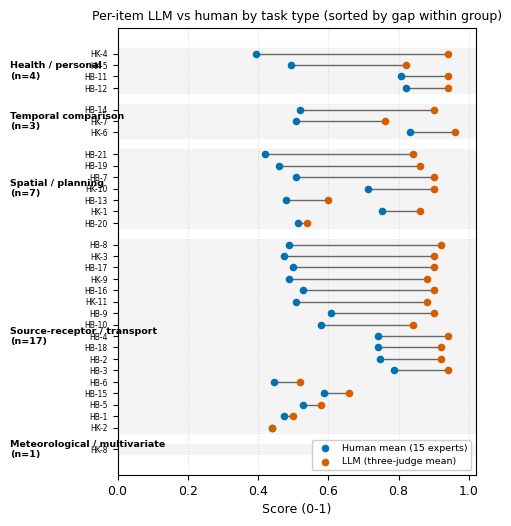

In [8]:
# Fig A (grouped by task type, compact). Task type inferred from query text;
# to correct any item, add it to `override` (label -> category) and re-run.
d=pd.read_pickle('figs/_disc_data.pkl').copy()
override={}   # e.g. {'HK-2':'Meteorological / multivariate'}
d['cat']=d.apply(lambda r: override.get(r['label'], r['ttype']), axis=1)
catorder=d.groupby('cat')['gap'].mean().sort_values(ascending=False).index.tolist()
rows=[]; ticks=[]; ylab=[]; spans=[]; y=0
for cat in catorder:
    g=d[d['cat']==cat].sort_values('gap',ascending=False)
    s=y
    for _,r in g.iterrows():
        rows.append(r); ticks.append(y); ylab.append(r['label']); y+=1
    spans.append((cat,s,y-1,len(g))); y+=0.9
R=pd.DataFrame(rows).reset_index(drop=True); yv=np.array(ticks)
fig,ax=plt.subplots(figsize=(6.4,5.8))
for cat,s,e,n in spans:
    ax.axhspan(s-0.45,e+0.45,color='#f4f4f4',zorder=0)
    ax.text(-0.30,(s+e)/2,f'{cat}\n(n={n})',ha='left',va='center',fontsize=6.8,
            fontweight='bold',transform=ax.get_yaxis_transform())
ax.hlines(yv,R['human'],R['llm_score'],color=CB['grey'],lw=1.0,zorder=2)
ax.scatter(R['human'],yv,s=20,color=CB['blue'],zorder=3,label='Human mean (15 experts)')
ax.scatter(R['llm_score'],yv,s=20,color=CB['orange'],zorder=3,label='LLM (three-judge mean)')
ax.set_yticks(yv); ax.set_yticklabels(ylab,fontsize=5.5); ax.invert_yaxis()
ax.set_xlim(0,1.02); ax.set_xlabel('Score (0-1)')
ax.set_title('Per-item LLM vs human by task type (sorted by gap within group)',fontsize=9)
ax.legend(loc='lower right',fontsize=6.8,framealpha=.95); ax.grid(axis='x',ls=':',alpha=.4)
plt.subplots_adjust(left=0.34)
plt.savefig('figs/fig_discrepancy_dumbbell.pdf',bbox_inches='tight')
plt.savefig('figs/fig_discrepancy_dumbbell.png',bbox_inches='tight')
print('saved grouped compact Fig A'); plt.show()

saved figs/fig_gap_by_tasktype.{pdf,png}


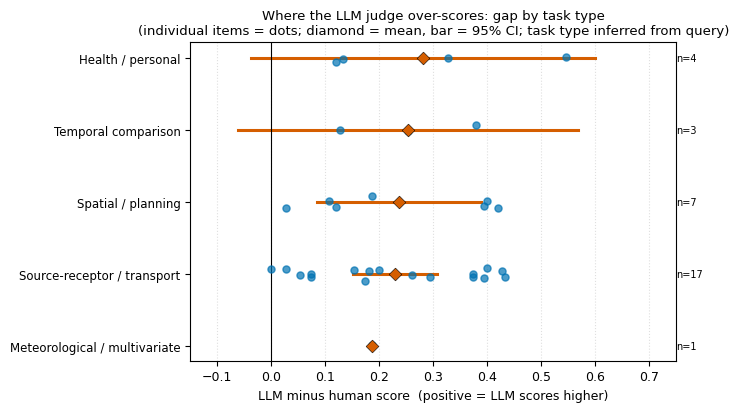

In [9]:
d=pd.read_pickle('figs/_disc_data.pkl')
order=d.groupby('ttype')['gap'].mean().sort_values().index.tolist()
fig,ax=plt.subplots(figsize=(7.2,4.2))
rng=np.random.default_rng(7)
for i,t in enumerate(order):
    g=d[d['ttype']==t]['gap'].values; n=len(g)
    xj=rng.uniform(-.09,.09,n)
    ax.scatter(g,np.full(n,i)+xj,s=26,color=CB['blue'],alpha=.7,zorder=3)
    mean=g.mean()
    if n>1:
        ci=stats.t.ppf(.975,n-1)*g.std(ddof=1)/np.sqrt(n)
        ax.plot([mean-ci,mean+ci],[i,i],color=CB['orange'],lw=2.2,zorder=2)
    ax.scatter([mean],[i],marker='D',s=42,color=CB['orange'],zorder=4,edgecolor='k',lw=.4)
    ax.text(1.0,i,f'n={n}',va='center',ha='left',fontsize=7,transform=ax.get_yaxis_transform())
ax.axvline(0,color='k',lw=.8)
ax.set_yticks(range(len(order))); ax.set_yticklabels(order,fontsize=8.5)
ax.set_xlabel('LLM minus human score  (positive = LLM scores higher)')
ax.set_title('Where the LLM judge over-scores: gap by task type\n(individual items = dots; diamond = mean, bar = 95% CI; task type inferred from query)',fontsize=9.5)
ax.grid(axis='x',ls=':',alpha=.4); ax.set_xlim(-.15,.75)
plt.tight_layout()
plt.savefig('figs/fig_gap_by_tasktype.pdf'); plt.savefig('figs/fig_gap_by_tasktype.png')
print('saved figs/fig_gap_by_tasktype.{pdf,png}'); plt.show()